In [1]:
import pandas as pd
import pyodbc
import matplotlib.pyplot as plt

In [2]:
mdb_path = r"C:\Users\Jouke\Desktop\emergo_dataset\DemoDataBetsyBike.mdb"

conn_str = (
    r"Driver={Microsoft Access Driver (*.mdb, *.accdb)};"
    fr"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)

C:\Users\Jouke\AppData\Local\Temp\ipykernel_5192\2479980919.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  t.table_name: pd.read_sql(f"SELECT * FROM [{t.table_name}]", conn)


Aantal regels: 119,108
Totaalomzet: €109,795,540.77

Omzet per productcategorie:


,Category,Revenue,Percentage
1,Bikes,94651172.70,86.21
3,Components,11802593.29,10.75
2,Clothing,2103446.53,1.92
0,Accessories,1238328.24,1.13


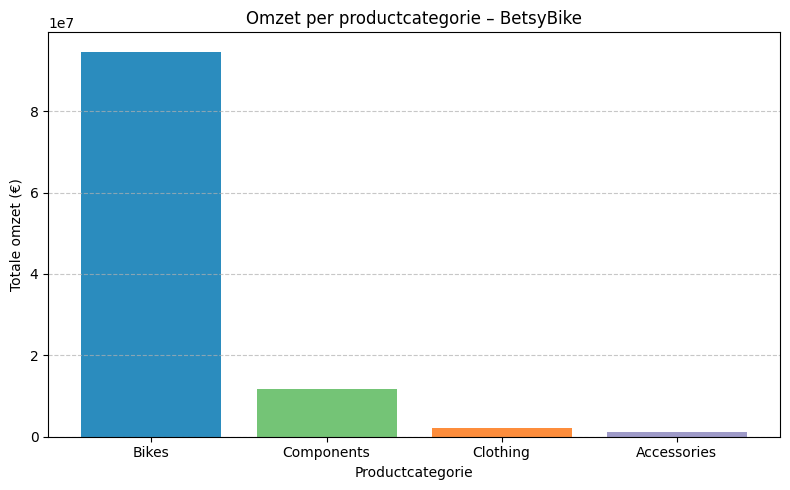

🏆 De productcategorie met de meeste omzet is 'Bikes' met een totale omzet van €94,651,172.70 (86.21% van de totale omzet).


In [3]:
# --- 3️⃣ Lees tabellen in ---
dfs = {
    t.table_name: pd.read_sql(f"SELECT * FROM [{t.table_name}]", conn)
    for t in conn.cursor().tables(tableType='TABLE')
}
conn.close()

# --- 4️⃣ Laad relevante tabellen ---
df_sales = dfs['SalesOrderDetail'].copy()
df_header = dfs['SalesOrderHeader'].copy()
df_product = dfs['Product'].copy()
df_subcat = dfs['ProductSubcategory'].copy()
df_category = dfs['ProductCategory'].copy()

# --- 5️⃣ Bereken omzet per orderregel ---
df_sales['Revenue'] = (
    df_sales['OrderQty'].astype(float)
    * df_sales['UnitPrice'].astype(float)
    * (1 - df_sales['UnitPriceDiscount'].astype(float))
)

# --- 6️⃣ Maak dimensies uniek ---
product_dim = (
    df_product[['ProductID', 'Name', 'ProductSubcategoryID']]
    .drop_duplicates(subset=['ProductID'])
    .rename(columns={'Name': 'ProductName'})
)
subcat_dim = df_subcat[['ProductSubcategoryID', 'ProductCategoryID']].drop_duplicates()
category_dim = (
    df_category[['ProductCategoryID', 'Name']]
    .drop_duplicates(subset=['ProductCategoryID'])
    .rename(columns={'Name': 'Category'})
)

# --- 7️⃣ Combineer alles in één dataset ---
sales_full = (
    df_sales
    .merge(df_header[['SalesOrderID', 'OrderDate']], on='SalesOrderID', how='left', validate='m:1')
    .merge(product_dim, on='ProductID', how='left', validate='m:1')
    .merge(subcat_dim, on='ProductSubcategoryID', how='left', validate='m:1')
    .merge(category_dim, on='ProductCategoryID', how='left', validate='m:1')
)

# --- 8️⃣ Controle: totaal aantal regels en omzet ---
print(f"Aantal regels: {len(sales_full):,}")
print(f"Totaalomzet: €{sales_full['Revenue'].sum():,.2f}")

# --- 9️⃣ Bereken omzet per productcategorie ---
category_revenue = (
    sales_full
    .groupby('Category', as_index=False)['Revenue']
    .sum()
    .sort_values('Revenue', ascending=False)
)
category_revenue['Percentage'] = (
    category_revenue['Revenue'] / category_revenue['Revenue'].sum() * 100
)

print("\nOmzet per productcategorie:")
display(category_revenue.round({'Revenue': 2, 'Percentage': 2}))

# --- 🔟 Visualiseer categorieomzet ---
plt.figure(figsize=(8,5))
plt.bar(category_revenue['Category'], category_revenue['Revenue'], color=['#2b8cbe', '#74c476', '#fd8d3c', '#9e9ac8'])
plt.title("Omzet per productcategorie – BetsyBike")
plt.xlabel("Productcategorie")
plt.ylabel("Totale omzet (€)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- 11️⃣ Highlight: categorie met hoogste omzet ---
top_category = category_revenue.iloc[0]
print(f"🏆 De productcategorie met de meeste omzet is '{top_category['Category']}' "
      f"met een totale omzet van €{top_category['Revenue']:,.2f} "
      f"({top_category['Percentage']:.2f}% van de totale omzet).")